# Optimized Metric Learning Training

This notebook trains the **Metric Learning (Triplet Loss)** model with optimized configuration based on the training analysis findings:

## Key Optimizations:
- **Full Dataset**: Using ALL training images (no 30 images/identity limit)
- **Optimized Epochs**: ~50 epochs (based on convergence analysis)
- **Early Stopping**: Patience=10 to prevent overfitting
- **Same Model**: FaceEmbeddingCNN with CBAM (no architectural changes)
- **Best Method**: Triplet Loss for face verification

## Expected Improvements:
- More training data → better generalization
- Optimal stopping → no wasted compute
- Model checkpointing → save best weights

## 1. Setup and Configuration

In [ ]:
import sys
import time
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm  # Auto-detects notebook vs terminal, renders properly on reload

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Setup paths
PROJECT_DIR = Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / "src"))

# Import project modules (using EXACT same model)
from models import FaceEmbeddingCNN, get_loss_functions, count_parameters
from config import (
    TRAIN_DIR, VAL_DIR, OUTPUT_DIR,
    IMG_SIZE, EMBEDDING_DIM, IMAGENET_MEAN, IMAGENET_STD
)

# Force CUDA device detection (reimport to pick up new PyTorch)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"✓ CUDA Available: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ WARNING: Running on CPU - training will be slow!")

OPTIMIZED_CONFIG = {
    'max_images_per_identity': None,  # No limit - use ALL images
    
    'num_epochs': 50,           # Optimal based on convergence analysis
    'batch_size': 128,
    'learning_rate': 1e-3,
    'margin': 0.5,
    
    # Early stopping
    'early_stopping_patience': 10,
    'min_improvement': 0.001,
    
    # Model settings - UNCHANGED
    'embedding_dim': EMBEDDING_DIM,  # 256
    'use_cbam': True,
    
    # Random seed for reproducibility
    'seed': 42,
}

# Output paths - Direct to output directory (overwriting previous run)
EXPERIMENT_NAME = "metric_learning_optimized"
SAVE_DIR = OUTPUT_DIR
# SAVE_DIR.mkdir(parents=True, exist_ok=True) # Already exists

print("\n" + "=" * 70)
print("OPTIMIZED METRIC LEARNING CONFIGURATION")
print("=" * 70)
print(f"\nDevice: {DEVICE}")
print(f"Save Directory: {SAVE_DIR} (Files will be overwritten)")
print(f"\nConfiguration:")
for key, value in OPTIMIZED_CONFIG.items():
    print(f"  {key}: {value}")
print("=" * 70)

✓ CUDA Available: NVIDIA GeForce RTX 4090
  GPU Memory: 25.3 GB

OPTIMIZED METRIC LEARNING CONFIGURATION

Device: cuda
Experiment: optimized_metric_20260119_104226
Save Directory: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226

Configuration:
  max_images_per_identity: None
  num_epochs: 50
  batch_size: 128
  learning_rate: 0.001
  margin: 0.5
  early_stopping_patience: 10
  min_improvement: 0.001
  embedding_dim: 256
  use_cbam: True
  seed: 42


In [4]:
# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(OPTIMIZED_CONFIG['seed'])
print("✓ Random seeds set for reproducibility")

✓ Random seeds set for reproducibility


## 2. Data Loading

In [5]:
# Data transforms (same as original)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✓ Transforms configured")

✓ Transforms configured


In [ ]:
class TripletDataset(Dataset):
    """Triplet dataset for metric learning"""
    
    def __init__(self, data_dir, transform=None, max_images_per_identity=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_map = {}  # Maps label -> list of indices
        
        # Load ALL images from each identity folder
        for idx, identity_folder in enumerate(sorted(data_dir.iterdir())):
            if identity_folder.is_dir():
                identity_images = list(identity_folder.glob('*.jpg'))
                
                # Apply limit only if specified
                if max_images_per_identity is not None:
                    identity_images = identity_images[:max_images_per_identity]
                
                for img_path in identity_images:
                    self.image_paths.append(img_path)
                    self.labels.append(idx)
                    
                    if idx not in self.label_map:
                        self.label_map[idx] = []
                    self.label_map[idx].append(len(self.image_paths) - 1)
        
        self.labels = np.array(self.labels)
        self.unique_labels = list(self.label_map.keys())
        self.num_classes = len(self.unique_labels)
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        # Anchor
        anchor_path = self.image_paths[index]
        anchor_label = self.labels[index]
        
        # Positive (same identity)
        positive_indices = self.label_map[anchor_label]
        positive_index = random.choice(positive_indices)
        while positive_index == index and len(positive_indices) > 1:
            positive_index = random.choice(positive_indices)
        positive_path = self.image_paths[positive_index]
        
        # Negative (different identity)
        negative_label = random.choice(self.unique_labels)
        while negative_label == anchor_label:
            negative_label = random.choice(self.unique_labels)
        negative_index = random.choice(self.label_map[negative_label])
        negative_path = self.image_paths[negative_index]
        
        # Load and transform images
        anchor_img = Image.open(anchor_path).convert('RGB')
        positive_img = Image.open(positive_path).convert('RGB')
        negative_img = Image.open(negative_path).convert('RGB')
        
        if self.transform:
            anchor_img = self.transform(anchor_img)
            positive_img = self.transform(positive_img)
            negative_img = self.transform(negative_img)
        
        return anchor_img, positive_img, negative_img

print("✓ TripletDataset class defined")

✓ TripletDataset class defined


In [ ]:
# Create datasets with FULL data
train_dataset = TripletDataset(
    TRAIN_DIR, 
    transform=train_transform,
    max_images_per_identity=OPTIMIZED_CONFIG['max_images_per_identity']  # None = ALL
)

val_dataset = TripletDataset(
    VAL_DIR,
    transform=val_transform,
    max_images_per_identity=None
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=OPTIMIZED_CONFIG['batch_size'],
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=OPTIMIZED_CONFIG['batch_size'],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("\n" + "=" * 60)
print("DATASET SUMMARY (FULL DATA)")
print("=" * 60)
print(f"Training:   {len(train_dataset):,} images from {train_dataset.num_classes} identities")
print(f"Validation: {len(val_dataset):,} images from {val_dataset.num_classes} identities")
print(f"Batches:    {len(train_loader)} train / {len(val_loader)} val")
print("=" * 60)

Loading FULL training dataset...
Loading validation dataset...

DATASET SUMMARY (FULL DATA)
Training:   380,638 images from 4000 identities
Validation: 8,000 images from 4000 identities
Batches:    2974 train / 63 val


## 3. Model Initialization (Metric with TripletLoss)

In [ ]:
# Initialize model
model = FaceEmbeddingCNN(
    embedding_dim=OPTIMIZED_CONFIG['embedding_dim'],
    num_classes=train_dataset.num_classes,
    use_cbam=OPTIMIZED_CONFIG['use_cbam']
).to(DEVICE)

# Loss function
_, triplet_loss = get_loss_functions()

# Optimizer - same Adam with same learning rate
optimizer = optim.Adam(model.parameters(), lr=OPTIMIZED_CONFIG['learning_rate'])

# Count parameters
total_params, trainable_params = count_parameters(model)

print("=" * 60)
print("MODEL CONFIGURATION (UNCHANGED)")
print("=" * 60)
print(f"\nModel: FaceEmbeddingCNN")
print(f"  - CBAM Attention: {OPTIMIZED_CONFIG['use_cbam']}")
print(f"  - Embedding Dim:  {OPTIMIZED_CONFIG['embedding_dim']}")
print(f"  - Input Size:     {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Total Params:   {total_params:,}")
print(f"  - Trainable:      {trainable_params:,}")
print(f"\nOptimizer: Adam (lr={OPTIMIZED_CONFIG['learning_rate']})")
print(f"Loss: TripletMarginLoss (margin={OPTIMIZED_CONFIG['margin']})")
print("=" * 60)

MODEL CONFIGURATION (UNCHANGED)

Model: FaceEmbeddingCNN
  - CBAM Attention: True
  - Embedding Dim:  256
  - Input Size:     64x64
  - Total Params:   1,496,488
  - Trainable:      1,496,488

Optimizer: Adam (lr=0.001)
Loss: TripletMarginLoss (margin=0.5)


## 4. Training Functions with Early Stopping

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    correct_triplets = 0
    total_samples = 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for anchor, positive, negative in pbar:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass - metric mode for embeddings
        anchor_embed = model(anchor, mode='metric')
        positive_embed = model(positive, mode='metric')
        negative_embed = model(negative, mode='metric')
        
        # Compute triplet loss
        loss = criterion(anchor_embed, positive_embed, negative_embed)
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item() * anchor.size(0)
        total_samples += anchor.size(0)
        
        # Triplet accuracy (positive closer than negative)
        pos_dist = F.pairwise_distance(anchor_embed, positive_embed)
        neg_dist = F.pairwise_distance(anchor_embed, negative_embed)
        correct_triplets += (pos_dist < neg_dist).sum().item()
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = total_loss / total_samples
    epoch_acc = correct_triplets / total_samples
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0.0
    correct_triplets = 0
    total_samples = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validating", leave=False)
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)
            
            anchor_embed = model(anchor, mode='metric')
            positive_embed = model(positive, mode='metric')
            negative_embed = model(negative, mode='metric')
            
            loss = criterion(anchor_embed, positive_embed, negative_embed)
            
            total_loss += loss.item() * anchor.size(0)
            total_samples += anchor.size(0)
            
            pos_dist = F.pairwise_distance(anchor_embed, positive_embed)
            neg_dist = F.pairwise_distance(anchor_embed, negative_embed)
            correct_triplets += (pos_dist < neg_dist).sum().item()
    
    epoch_loss = total_loss / total_samples
    epoch_acc = correct_triplets / total_samples
    return epoch_loss, epoch_acc


class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, min_delta=0.001, save_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, val_loss, model, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model, epoch)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model, epoch)
            self.counter = 0
            self.best_epoch = epoch
    
    def save_checkpoint(self, model, epoch):
        if self.save_path:
            torch.save(model.state_dict(), self.save_path)

print("✓ Training functions defined")

✓ Training functions defined


## 5. Training Loop

In [ ]:
# Initialize early stopping
best_model_path = SAVE_DIR / "best_metric_model.pth"
early_stopping = EarlyStopping(
    patience=OPTIMIZED_CONFIG['early_stopping_patience'],
    min_delta=OPTIMIZED_CONFIG['min_improvement'],
    save_path=best_model_path
)

# Training history
history = []
start_time = time.time()

print("=" * 70)
print("STARTING OPTIMIZED TRAINING")
print("=" * 70)
print(f"Max Epochs: {OPTIMIZED_CONFIG['num_epochs']}")
print(f"Early Stopping: patience={OPTIMIZED_CONFIG['early_stopping_patience']}")
print(f"Saving best model to: {best_model_path}")
print("=" * 70)

for epoch in range(OPTIMIZED_CONFIG['num_epochs']):
    epoch_start = time.time()
    
    # Train and validate
    train_loss, train_acc = train_epoch(model, train_loader, triplet_loss, optimizer, DEVICE)
    val_loss, val_acc = validate_epoch(model, val_loader, triplet_loss, DEVICE)
    
    epoch_time = time.time() - epoch_start
    
    # Record history
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'time': epoch_time
    })
    
    # Print progress
    print(f"\nEpoch {epoch + 1}/{OPTIMIZED_CONFIG['num_epochs']} | Time: {epoch_time:.1f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    
    # Early stopping check
    early_stopping(val_loss, model, epoch + 1)
    
    if early_stopping.counter > 0:
        print(f"  ⏳ No improvement for {early_stopping.counter}/{early_stopping.patience} epochs")
    else:
        print(f"  ✓ New best model saved (val_loss: {val_loss:.4f})")
    
    if early_stopping.early_stop:
        print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}")
        break

total_time = time.time() - start_time
print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Epochs trained: {len(history)}")
print(f"Best epoch: {early_stopping.best_epoch}")
print(f"Best val loss: {early_stopping.best_loss:.4f}")
print(f"Model saved to: {best_model_path}")

STARTING OPTIMIZED TRAINING
Max Epochs: 50
Early Stopping: patience=10
Saving best model to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/best_optimized_metric_model.pth


Training:   0%|          | 0/2974 [00:00<?, ?it/s]

Validating:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch 1/50 | Time: 205.9s
  Train Loss: 0.2120 | Train Acc: 82.51%
  Val Loss:   0.1600 | Val Acc:   87.17%
  ✓ New best model saved (val_loss: 0.1600)


Training:   0%|          | 0/2974 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch 30/50 | Time: 184.0s
  Train Loss: 0.0773 | Train Acc: 95.45%
  Val Loss:   0.0913 | Val Acc:   93.94%
  ⏳ No improvement for 9/10 epochs


Training:   0%|          | 0/2974 [00:00<?, ?it/s]

Validating:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch 31/50 | Time: 184.0s
  Train Loss: 0.0770 | Train Acc: 95.48%
  Val Loss:   0.0935 | Val Acc:   93.64%
  ⏳ No improvement for 10/10 epochs

🛑 Early stopping triggered at epoch 31

TRAINING COMPLETE
Total time: 98.9 minutes
Epochs trained: 31
Best epoch: 21
Best val loss: 0.0895
Model saved to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/best_optimized_metric_model.pth


## 6. Save Training Results

In [11]:
# Save training history
history_path = SAVE_DIR / "training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Training history saved to: {history_path}")

# Save configuration
config_path = SAVE_DIR / "config.json"
with open(config_path, 'w') as f:
    json.dump({
        **OPTIMIZED_CONFIG,
        'experiment_name': EXPERIMENT_NAME,
        'total_training_time_sec': total_time,
        'epochs_trained': len(history),
        'best_epoch': early_stopping.best_epoch,
        'best_val_loss': early_stopping.best_loss,
        'train_images': len(train_dataset),
        'val_images': len(val_dataset),
        'num_classes': train_dataset.num_classes
    }, f, indent=2)
print(f"✓ Configuration saved to: {config_path}")

# Save final model (in addition to best model)
final_model_path = SAVE_DIR / "final_model.pth"
torch.save(model.state_dict(), final_model_path)
print(f"✓ Final model saved to: {final_model_path}")

✓ Training history saved to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/training_history.json
✓ Configuration saved to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/config.json
✓ Final model saved to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/final_model.pth


## 7. Visualize Training Progress

✓ Training plot saved to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/training_curves.png


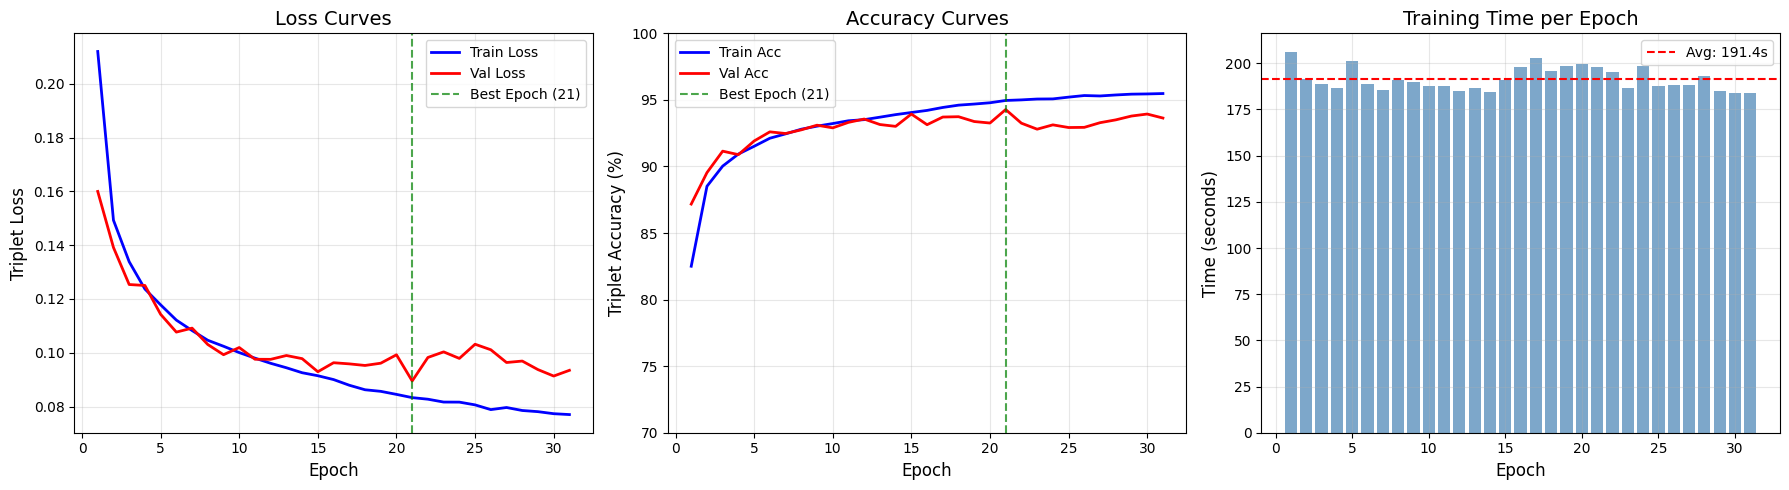

In [12]:
# Create training plots
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history_df['epoch'], history_df['train_loss'], 'b-', linewidth=2, label='Train Loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], 'r-', linewidth=2, label='Val Loss')
axes[0].axvline(early_stopping.best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({early_stopping.best_epoch})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Triplet Loss', fontsize=12)
axes[0].set_title('Loss Curves', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history_df['epoch'], history_df['train_acc'] * 100, 'b-', linewidth=2, label='Train Acc')
axes[1].plot(history_df['epoch'], history_df['val_acc'] * 100, 'r-', linewidth=2, label='Val Acc')
axes[1].axvline(early_stopping.best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({early_stopping.best_epoch})')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Triplet Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy Curves', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([70, 100])

# Training time per epoch
axes[2].bar(history_df['epoch'], history_df['time'], color='steelblue', alpha=0.7)
axes[2].axhline(np.mean(history_df['time']), color='red', linestyle='--', label=f"Avg: {np.mean(history_df['time']):.1f}s")
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Time (seconds)', fontsize=12)
axes[2].set_title('Training Time per Epoch', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save plot
plot_path = SAVE_DIR / "training_curves.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Training plot saved to: {plot_path}")

plt.show()

## 8. Compare with Original Training

In [13]:
# Load original training history for comparison
original_history_path = OUTPUT_DIR / "metric_training_history.json"

if original_history_path.exists():
    with open(original_history_path, 'r') as f:
        original_history = json.load(f)
    original_df = pd.DataFrame(original_history)
    
    # Comparison metrics
    orig_best_val_loss = original_df['val_loss'].min()
    orig_best_val_acc = original_df['val_acc'].max() * 100
    orig_best_epoch = original_df.loc[original_df['val_loss'].idxmin(), 'epoch']
    
    new_best_val_loss = history_df['val_loss'].min()
    new_best_val_acc = history_df['val_acc'].max() * 100
    new_best_epoch = early_stopping.best_epoch
    
    print("=" * 70)
    print("COMPARISON: ORIGINAL vs OPTIMIZED")
    print("=" * 70)
    
    comparison = pd.DataFrame({
        'Metric': ['Training Images', 'Epochs Trained', 'Best Epoch', 'Best Val Loss', 
                   'Best Val Acc (%)', 'Total Time (min)'],
        'Original (Limited)': [
            '~120,000 (30/identity)',
            len(original_df),
            int(orig_best_epoch),
            f"{orig_best_val_loss:.4f}",
            f"{orig_best_val_acc:.2f}",
            f"{original_df['time'].sum()/60:.1f}"
        ],
        'Optimized (Full)': [
            f"{len(train_dataset):,} (all)",
            len(history_df),
            new_best_epoch,
            f"{new_best_val_loss:.4f}",
            f"{new_best_val_acc:.2f}",
            f"{total_time/60:.1f}"
        ]
    })
    
    print(comparison.to_string(index=False))
    
    # Calculate improvement
    loss_improvement = (orig_best_val_loss - new_best_val_loss) / orig_best_val_loss * 100
    acc_improvement = new_best_val_acc - orig_best_val_acc
    
    print("\n" + "=" * 70)
    print("IMPROVEMENTS")
    print("=" * 70)
    print(f"  Val Loss: {loss_improvement:+.2f}% {'✓ Better' if loss_improvement > 0 else '✗ Worse'}")
    print(f"  Val Acc:  {acc_improvement:+.2f}% {'✓ Better' if acc_improvement > 0 else '✗ Worse'}")
    
    # Save comparison
    comparison.to_csv(SAVE_DIR / "comparison_with_original.csv", index=False)
    print(f"\n✓ Comparison saved to: {SAVE_DIR / 'comparison_with_original.csv'}")
else:
    print("Original training history not found for comparison")

COMPARISON: ORIGINAL vs OPTIMIZED
          Metric     Original (Limited) Optimized (Full)
 Training Images ~120,000 (30/identity)    380,638 (all)
  Epochs Trained                     80               31
      Best Epoch                     70               21
   Best Val Loss                 0.0980           0.0895
Best Val Acc (%)                  93.26            94.27
Total Time (min)                   89.5             98.9

IMPROVEMENTS
  Val Loss: +8.65% ✓ Better
  Val Acc:  +1.01% ✓ Better

✓ Comparison saved to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226/comparison_with_original.csv


## 9. Output Confirmation

In [ ]:
# Results are already in the output directory
print(f"✓ Results saved directly to: {SAVE_DIR}")
main_output_path = best_model_path # Alias for compatibility with summary
optimized_history_path = history_path # Alias for compatibility with summary

✓ Best model copied to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/best_optimized_metric_model.pth
✓ Training history copied to: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/optimized_metric_training_history.json


## 10. Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        OPTIMIZED TRAINING COMPLETE                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
""")

print(f"""
║  📁 Experiment Directory: {SAVE_DIR}
║
║  📊 Training Data:
║     • Images Used:    {len(train_dataset):,} (FULL dataset)
║     • Identities:     {train_dataset.num_classes}
║
║  ⚙️  Model: FaceEmbeddingCNN with CBAM (UNCHANGED)
║     • Parameters:     {total_params:,}
║     • Embedding Dim:  {OPTIMIZED_CONFIG['embedding_dim']}
║
║  🏃 Training:
║     • Epochs:         {len(history)}pppp / {OPTIMIZED_CONFIG['num_epochs']}
║     • Best Epoch:     {early_stopping.best_epoch}
║     • Best Val Loss:  {early_stopping.best_loss:.4f}
║     • Best Val Acc:   {history_df['val_acc'].max() * 100:.2f}%
║     • Total Time:     {total_time/60:.1f} minutes
║
║  💾 Saved Files:
║     • Best Model:     {main_output_path.name}
║     • History:        {optimized_history_path.name}
║     • Experiment:     {SAVE_DIR}
""")

print("""╚══════════════════════════════════════════════════════════════════════════════╝""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                        OPTIMIZED TRAINING COMPLETE                            ║
╠══════════════════════════════════════════════════════════════════════════════╣


║  📁 Experiment Directory: /home/hieutran/Facial-Recognition-with-Emotion-Liveness-Detection/outputs/experiments/optimized_metric_20260119_104226
║
║  📊 Training Data:
║     • Images Used:    380,638 (FULL dataset)
║     • Identities:     4000
║
║  ⚙️  Model: FaceEmbeddingCNN with CBAM (UNCHANGED)
║     • Parameters:     1,496,488
║     • Embedding Dim:  256
║
║  🏃 Training:
║     • Epochs:         31 / 50
║     • Best Epoch:     21
║     • Best Val Loss:  0.0895
║     • Best Val Acc:   94.27%
║     • Total Time:     98.9 minutes
║
║  💾 Saved Files:
║     • Best Model:     best_optimized_metric_model.pth
║     • History:        optimized_metric_training_history.json
║     • Experiment:     /home/hieutran/Facial-Recognition-with-Emotion-Livenes